### Multiple Linear Regression

#### Problem Statement: 
#### To Predict CO2 Emission

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import re
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
ALPHA = 0.05 

In [59]:
df = pd.read_csv('../Datasets/co2.csv')

In [60]:
backup = df.copy()

In [61]:
df.shape

(7385, 12)

In [62]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.000,4,AS5,Z,9.900,6.700,8.500,33,196
1,ACURA,ILX,COMPACT,2.400,4,M6,Z,11.200,7.700,9.600,29,221
2,ACURA,ILX HYBRID,COMPACT,1.500,4,AV7,Z,6.000,5.800,5.900,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.500,6,AS6,Z,12.700,9.100,11.100,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.500,6,AS6,Z,12.100,8.700,10.600,27,244


In [63]:
df.sample(5, random_state=RANDOM_STATE)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7261,PORSCHE,Panamera 4 Executive,FULL-SIZE,3.000,6,AM8,Z,12.400,9.000,10.900,26,253
4489,BMW,M6 CABRIOLET,SUBCOMPACT,4.400,8,AM7,Z,17.300,11.600,14.700,19,344
1539,GMC,SIERRA,PICKUP TRUCK - STANDARD,6.200,8,A8,Z,16.100,11.400,14.000,20,322
3532,CHEVROLET,SILVERADO,PICKUP TRUCK - STANDARD,5.300,8,A6,X,14.600,10.300,12.700,22,297
6418,TOYOTA,4Runner 4WD,SUV - STANDARD,4.000,6,AS5,X,14.300,11.900,13.200,21,308


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [65]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,7385,42,FORD,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,7385,2053,F-150 FFV 4X4,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Class,7385,16,SUV - SMALL,1217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine Size(L),7385.000,NaN,NaN,NaN,3.160,1.354,0.900,2.000,3.000,3.700,8.400
Cylinders,7385.000,NaN,NaN,NaN,5.615,1.828,3.000,4.000,6.000,6.000,16.000
Transmission,7385,27,AS6,1324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,7385,5,X,3637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Consumption City (L/100 km),7385.000,NaN,NaN,NaN,12.557,3.500,4.200,10.100,12.100,14.600,30.600
Fuel Consumption Hwy (L/100 km),7385.000,NaN,NaN,NaN,9.042,2.224,4.000,7.500,8.700,10.200,20.600
Fuel Consumption Comb (L/100 km),7385.000,NaN,NaN,NaN,10.975,2.893,4.100,8.900,10.600,12.600,26.100


In [66]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.000,3.160,1.354,0.900,2.000,3.000,3.700,8.400
Cylinders,7385.000,5.615,1.828,3.000,4.000,6.000,6.000,16.000
Fuel Consumption City (L/100 km),7385.000,12.557,3.500,4.200,10.100,12.100,14.600,30.600
Fuel Consumption Hwy (L/100 km),7385.000,9.042,2.224,4.000,7.500,8.700,10.200,20.600
Fuel Consumption Comb (L/100 km),7385.000,10.975,2.893,4.100,8.900,10.600,12.600,26.100
Fuel Consumption Comb (mpg),7385.000,27.482,7.232,11.000,22.000,27.000,32.000,69.000
CO2 Emissions(g/km),7385.000,250.585,58.513,96.000,208.000,246.000,288.000,522.000


In [67]:
df.describe(include='object').T

,count,unique,top,freq
Make,7385,42,FORD,628
Model,7385,2053,F-150 FFV 4X4,32
Vehicle Class,7385,16,SUV - SMALL,1217
Transmission,7385,27,AS6,1324
Fuel Type,7385,5,X,3637


In [68]:
pd.DataFrame({
    'dtype': df.dtypes,
    'missing_values': df.isnull().sum(),
    'missing_%' : (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique()
})

,dtype,missing_values,missing_%,unique_values
Make,object,0,0.000,42
Model,object,0,0.000,2053
Vehicle Class,object,0,0.000,16
Engine Size(L),float64,0,0.000,51
Cylinders,int64,0,0.000,8
Transmission,object,0,0.000,27
Fuel Type,object,0,0.000,5
Fuel Consumption City (L/100 km),float64,0,0.000,211
Fuel Consumption Hwy (L/100 km),float64,0,0.000,143
Fuel Consumption Comb (L/100 km),float64,0,0.000,181


In [69]:
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  1103


In [70]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
duplicate_rows.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3313,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.400,6.800,8.200,34,192
4371,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.400,6.800,8.200,34,192
5454,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.900,7.000,8.600,33,199
6503,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.900,7.000,8.600,33,199
3316,ACURA,MDX HYBRID AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
4374,ACURA,MDX HYBRID AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
5457,ACURA,MDX Hybrid AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
6506,ACURA,MDX Hybrid AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
3314,ACURA,MDX SH-AWD,SUV - SMALL,3.500,6,AS9,Z,12.600,9.000,11.000,26,259
4372,ACURA,MDX SH-AWD,SUV - SMALL,3.500,6,AS9,Z,12.600,9.000,11.000,26,259


In [71]:
df[df.duplicated(keep=False)].value_counts()

Make      Model          Vehicle Class   Engine Size(L)  Cylinders  Transmission  Fuel Type  Fuel Consumption City (L/100 km)  Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  Fuel Consumption Comb (mpg)  CO2 Emissions(g/km)
LEXUS     GS F           COMPACT         5.000           8          AS8           Z          14.900                            9.700                            12.500                            23                           293                    5
          NX 300h AWD    SUV - SMALL     2.500           4          AV6           X          7.200                             7.900                            7.500                             38                           176                    4
NISSAN    370Z           TWO-SEATER      3.700           6          AS7           Z          12.600                            9.300                            11.100                            25                           261                    4
CHRYSLER  300

In [72]:
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [73]:
df.shape

(6282, 12)

In [35]:
print("Duplicate Rows: ", df.duplicated().sum()) 

Duplicate Rows:  0


In [74]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,6282,42,FORD,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,6282,2053,F-150 FFV,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Class,6282,16,SUV - SMALL,1006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine Size(L),6282.000,NaN,NaN,NaN,3.162,1.365,0.900,2.000,3.000,3.700,8.400
Cylinders,6282.000,NaN,NaN,NaN,5.619,1.846,3.000,4.000,6.000,6.000,16.000
Transmission,6282,27,AS6,1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,6282,5,X,3039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Consumption City (L/100 km),6282.000,NaN,NaN,NaN,12.610,3.553,4.200,10.100,12.100,14.700,30.600
Fuel Consumption Hwy (L/100 km),6282.000,NaN,NaN,NaN,9.071,2.279,4.000,7.500,8.700,10.300,20.600
Fuel Consumption Comb (L/100 km),6282.000,NaN,NaN,NaN,11.018,2.947,4.100,8.900,10.600,12.700,26.100


In [76]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']

print(f"We have {len(categorical_features)} categoriacal features: {categorical_features}")
print()
print(f"We have {len(numerical_features)} numerical features: {numerical_features}")

We have 5 categoriacal features: ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

We have 7 numerical features: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


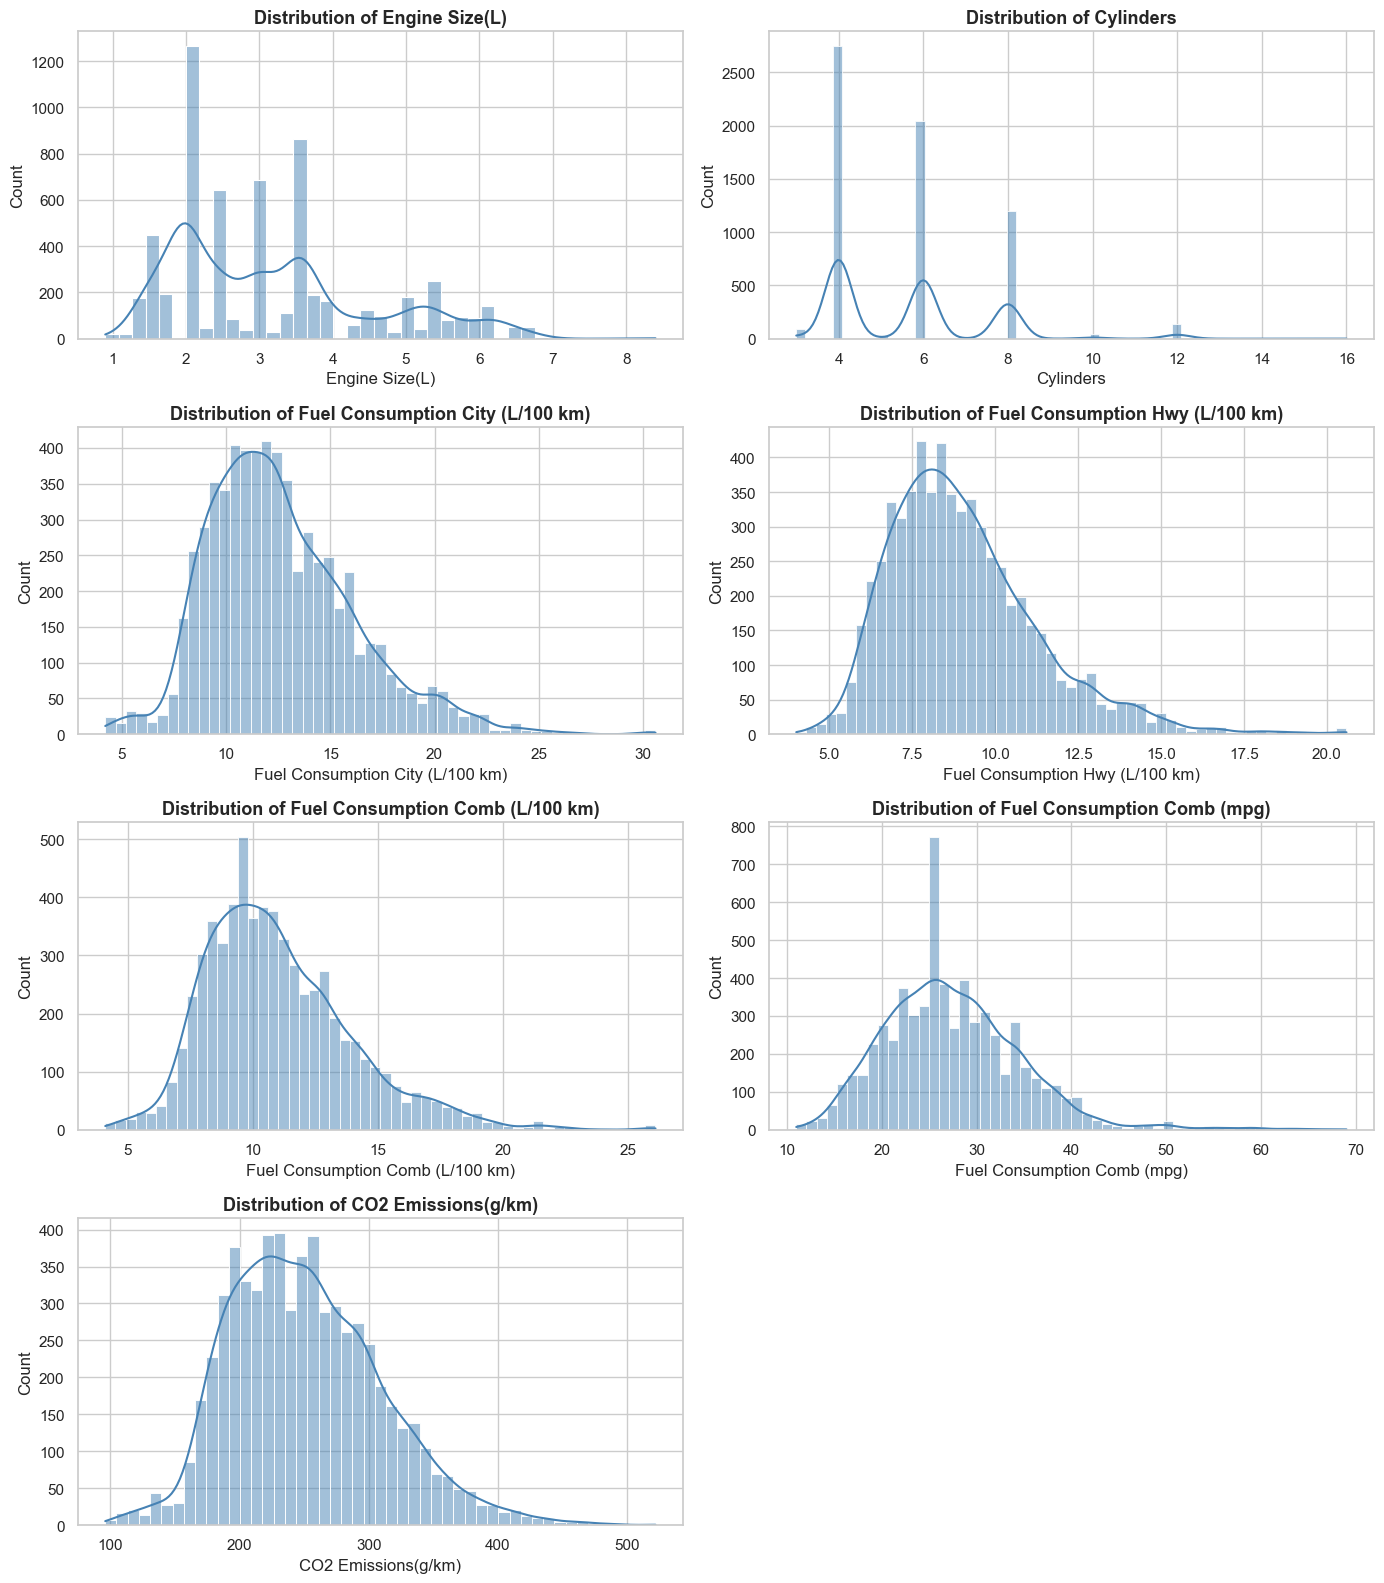

In [77]:
fig, axes = plt.subplots(nrows=(len(numerical_features)+1)//2, ncols=2, figsize=(14, 4*((len(numerical_features)+1)//2)))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()